<div style="text-align: left; margin-bottom: 20px;">
<img src="https://umd-brand.transforms.svdcdn.com/production/uploads/images/logos-primary.jpg?w=1801&h=601&auto=compress%2Cformat&fit=crop&dm=1613775207&s=71ce45031f9164cb409f11a2e28d8b8c"
alt="UMD Logo" style="max-width: 300px; height: auto;" />
</div>

# DATA/MSML 641: Natural Language Processing
## Lecture 11: Masked Language Models and LLM Post-Training
**University of Maryland, College Park**  
**Fall 2025**  
**Instructor**: Armin Mehrabian  
**Date**: November 17–18, 2025  

## Setup and Imports

In [1]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Transformers and PyTorch
import torch
import torch.nn as nn
from transformers import (
    BertTokenizer, BertModel, BertForMaskedLM,
    BertForSequenceClassification, BertForTokenClassification,
    AutoTokenizer, AutoModelForCausalLM,
    pipeline, Trainer, TrainingArguments
)

# Utilities
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from scipy.spatial.distance import cosine
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Configure plotting
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except:
    plt.style.use('seaborn-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("✓ Setup complete!")

/Users/amehrabi/miniconda3/envs/gwu/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ Setup complete!


<div style="text-align: left; margin-bottom: 20px;">
  <img src="https://umd-brand.transforms.svdcdn.com/production/uploads/images/logos-primary.jpg?w=1801&h=601&auto=compress%2Cformat&fit=crop&dm=1613775207&s=71ce45031f9164cb409f11a2e28d8b8c" 
       alt="UMD Logo" style="max-width: 300px; height: auto;" />
</div>

# Part 1: Tokenization



# Tokenization

Tokenization is the process of breaking down a body of text into smaller units, called tokens, such as **words**, **punctuation marks**, or even parts of words.

## Example: Tokenization for BERT

### Why Tokenization Matters

Before BERT can process text, we must convert it into tokens the model understands.

**Challenge**: Balance between vocabulary size and representation quality

### Three Approaches

1. **Character-level**: Very long sequences, small vocabulary
2. **Word-level**: Huge vocabulary, can't handle new words
3. **Subword-level**: Balance - BERT's choice

**BERT uses WordPiece tokenization** with ~30K tokens

## WordPiece Tokenization

### How It Works

- Learns subword units from training data
- Frequent words stay whole: "the", "cat", "run"
- Rare words split into pieces: "unhappiness" → "un", "##happi", "##ness"
- Prefix `##` marks word continuation

### Special Tokens

- **[CLS]**: Start token for classification
- **[SEP]**: Separator between sentences
- **[MASK]**: Replaces masked tokens during training
- **[PAD]**: Padding for batching
- **[UNK]**: Unknown/rare tokens

### Benefits

- Handles any text (no out-of-vocabulary)
- Captures morphology: "run" + "##ning"
- Compact: 30K tokens vs millions of words

## Byte Pair Encoding (BPE)

**What is BPE?**  
A subword tokenization algorithm adapted from data compression.

**Why it exists**
- Word-level → too many tokens  
- Character-level → very long sequences  
- BPE → balance between vocabulary size & sequence length  

**Used in**
- GPT-2  
- RoBERTa  
- INDUS (domain tokenizer)


## Tokenization Example: Same Text, Different Tokens

**Original text:**  
“Large language models reshape software development”

- **Character-level**  
  `[L][a][r][g][e][ ][l][a] … [n][t]`  
  (~50 tokens)

- **Word-level**  
  `[Large] [language] [models] [reshape] [software] [development]`  
  (6 tokens)

- **BPE / subword (e.g., GPT-style)**  
  `[Large] [language] [model][s] [re][shape] [software] [develop][ment]`  
  (9 tokens)

**Sweet Spot:** Subword tokenization sits between characters and words → shorter sequences than characters, more flexible than pure word vocabularies.


## From Tokens to IDs

Tokenizers don’t output text — they output integers.

Why?
Transformers operate on numbers, not strings.

Example (conceptual):
"Large" → 1337
"language" → 4921
"model" → 2012
"##s" or "Ġs" → 87

These IDs index into an embedding matrix during model input.


## Real-World Implications of Tokenization

1. **Long, rare words are split across many tokens**  
   Example: “electroencephalographically” → `[electro][encephalo][graph][ic][ally]`

2. **Cross-lingual context unfairness**

   - English: “I study machine learning every day.” → ~8 tokens  
   - Chinese: “我每天学习机器学习。” → ~12–14 tokens  
   - Japanese: “私は毎日機械学習を勉強します。” → ~15+ tokens  

English users fit more information into the same context window.

**Token Information Density (TID):**  
$$ \text{TID}(\text{language}, V) = \frac{\text{information content}}{\text{token count}} $$






## Domain-Specific Tokenizers: INDUS Example

### NASA-IBM INDUS Model

**Problem**: General tokenizers (like RoBERTa) may not be optimal for specialized domains

**Solution**: Train custom **INDUSBPE tokenizer** on domain-specific data

### INDUSBPE Characteristics

- **Method**: Byte Pair Encoding (BPE)
- **Vocabulary size**: 50,265 tokens (same as RoBERTa)
- **Training data**: Aerospace/scientific domain corpus

### Comparison with RoBERTa Tokenizer

| Metric | Value |
|--------|-------|
| Shared vocabulary | 44.5% |
| Domain-specific tokens | 55.5% |
| Computation reduction | 8% fewer tokens |

**Why this matters**: Domain-specific tokenizers produce fewer, more meaningful tokens for specialized text, reducing training cost and improving performance.

In [2]:
# WordPiece tokenization examples
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Examples
examples = [
    "running",
    "unhappiness",
    "COVID-19",
    "The cat sat on the mat."
]

print("WordPiece Tokenization Examples:\n")
print("=" * 60)

for text in examples:
    tokens = tokenizer.tokenize(text)
    token_ids = tokenizer.convert_tokens_to_ids(tokens)
    
    print(f"\nText: {text}")
    print(f"Tokens: {tokens}")
    print(f"IDs: {token_ids}")

print("\n" + "=" * 60)
print("\nNote: ## prefix indicates subword continuation")
print("\nKey Insight from INDUS:")
print("Domain-specific tokenizers can reduce tokens by 8%,")
print("directly saving computation during training.")

WordPiece Tokenization Examples:


Text: running
Tokens: ['running']
IDs: [2770]

Text: unhappiness
Tokens: ['un', '##ha', '##pp', '##iness']
IDs: [4895, 3270, 9397, 9961]

Text: COVID-19
Tokens: ['co', '##vid', '-', '19']
IDs: [2522, 17258, 1011, 2539]

Text: The cat sat on the mat.
Tokens: ['the', 'cat', 'sat', 'on', 'the', 'mat', '.']
IDs: [1996, 4937, 2938, 2006, 1996, 13523, 1012]


Note: ## prefix indicates subword continuation

Key Insight from INDUS:
Domain-specific tokenizers can reduce tokens by 8%,
directly saving computation during training.


<div style="text-align: left; margin-bottom: 20px;">
  <img src="https://umd-brand.transforms.svdcdn.com/production/uploads/images/logos-primary.jpg?w=1801&h=601&auto=compress%2Cformat&fit=crop&dm=1613775207&s=71ce45031f9164cb409f11a2e28d8b8c" 
       alt="UMD Logo" style="max-width: 300px; height: auto;" />
</div>



# Part 2: Masked Language Models (BERT)


## From Causal to Bidirectional Language Models

### Causal (Unidirectional) Language Models
- **GPT-style models**: Predict next token given previous tokens
- **Limitation**: Only left-to-right context
- **Use case**: Text generation

### Bidirectional Language Models
- **BERT-style models**: Use both left and right context
- **Advantage**: Richer representations for understanding tasks
- **Use case**: Classification, NER, question answering, etc.

### Key Insight
> **Question**: How can we train a model to use bidirectional context without "cheating" (seeing the answer during training)?
>
> **Answer**: Masked Language Modeling (MLM)

## 1.2 Bidirectional Self-Attention

### Causal vs. Bidirectional Attention

**Causal Self-Attention** (GPT):
- Uses attention mask to prevent looking at future tokens
- Token at position $i$ can only attend to positions $\leq i$
- Attention mask is lower triangular

**Bidirectional Self-Attention** (BERT):
- No masking constraint
- Token at position $i$ can attend to all positions
- Full attention matrix (not triangular)

### Attention Mechanism Recap

$$
\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V
$$

Where:
- $Q$ = Query matrix
- $K$ = Key matrix
- $V$ = Value matrix
- $d_k$ = dimension of key vectors

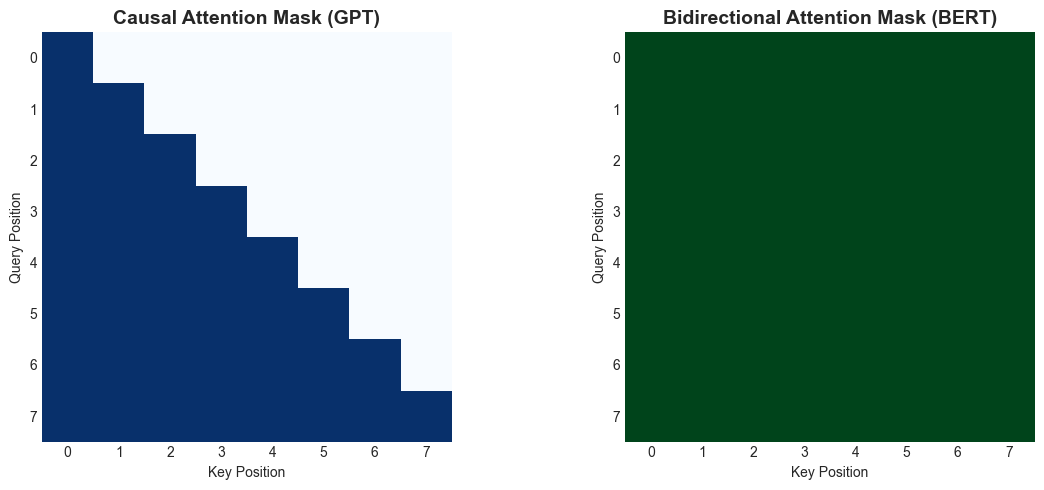


 Interpretation:
- Blue cell = Can attend | White cell = Cannot attend
- Causal: Each position can only see previous positions
- Bidirectional: Each position can see all positions


In [3]:
# Visualize causal vs bidirectional attention masks
def visualize_attention_masks():
    seq_len = 8

    # Causal mask (lower triangular)
    causal_mask = np.tril(np.ones((seq_len, seq_len)))

    # Bidirectional mask (all ones)
    bidirectional_mask = np.ones((seq_len, seq_len))

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].imshow(causal_mask, cmap='Blues', vmin=0, vmax=1)
    axes[0].set_title('Causal Attention Mask (GPT)', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Key Position')
    axes[0].set_ylabel('Query Position')
    axes[0].grid(False)

    axes[1].imshow(bidirectional_mask, cmap='Greens', vmin=0, vmax=1)
    axes[1].set_title('Bidirectional Attention Mask (BERT)', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Key Position')
    axes[1].set_ylabel('Query Position')
    axes[1].grid(False)

    plt.tight_layout()
    plt.show()

    print("\n Interpretation:")
    print("- Blue cell = Can attend | White cell = Cannot attend")
    print("- Causal: Each position can only see previous positions")
    print("- Bidirectional: Each position can see all positions")

visualize_attention_masks()

## 1.3 BERT Architecture

### BERT: Bidirectional Encoder Representations from Transformers

**Key Features**:
- **Architecture**: Stack of transformer encoder layers
- **Attention**: Bidirectional (full) self-attention
- **Training**: Masked Language Modeling (MLM) + Next Sentence Prediction (NSP)
- **Output**: Contextual embeddings for each token

### BERT Variants

| Model | Layers | Hidden Size | Attention Heads | Parameters |
|-------|--------|-------------|-----------------|------------|
| BERT-Base | 12 | 768 | 12 | 110M |
| BERT-Large | 24 | 1024 | 16 | 340M |

### Special Tokens
- **[CLS]**: Classification token (first token, used for sequence-level tasks)
- **[SEP]**: Separator token (separates sentences)
- **[MASK]**: Mask token (replaces masked words during training)
- **[PAD]**: Padding token (for batching sequences of different lengths)

In [4]:
# Load BERT model and tokenizer
model_name = 'bert-base-uncased'
tokenizer = BertTokenizer.from_pretrained(model_name)
bert_model = BertModel.from_pretrained(model_name)

# Example sentence
text = "The cat sat on the mat."

# Tokenize
tokens = tokenizer.tokenize(text)
print(f"Original text: {text}")
print(f"Tokens: {tokens}")

# Add special tokens
tokens_with_special = ['[CLS]'] + tokens + ['[SEP]']
print(f"\nWith special tokens: {tokens_with_special}")

# Convert to IDs
token_ids = tokenizer.convert_tokens_to_ids(tokens_with_special)
print(f"Token IDs: {token_ids}")

# Get embeddings
input_ids = torch.tensor([token_ids])
with torch.no_grad():
    outputs = bert_model(input_ids)
    embeddings = outputs.last_hidden_state

print(f"\nEmbedding shape: {embeddings.shape}")
print(f"(batch_size, sequence_length, hidden_size) = {embeddings.shape}")

Original text: The cat sat on the mat.
Tokens: ['the', 'cat', 'sat', 'on', 'the', 'mat', '.']

With special tokens: ['[CLS]', 'the', 'cat', 'sat', 'on', 'the', 'mat', '.', '[SEP]']
Token IDs: [101, 1996, 4937, 2938, 2006, 1996, 13523, 1012, 102]

Embedding shape: torch.Size([1, 9, 768])
(batch_size, sequence_length, hidden_size) = torch.Size([1, 9, 768])


## 1.4 Masked Language Modeling (MLM)

### Training Objective

**Goal**: Predict masked tokens using bidirectional context

**Procedure**:
1. Randomly select 15% of tokens
2. For selected tokens:
- 80% of the time: Replace with [MASK]
- 10% of the time: Replace with random word
- 10% of the time: Keep unchanged
3. Predict original tokens

### Why This Strategy?

**Problem with always using [MASK]**:
- During fine-tuning, there's no [MASK] token
- Model might overfit to [MASK] token

**Solution**:
- 10% random: Forces model to use context, not just [MASK]
- 10% unchanged: Model learns to use original token information

### MLM Loss

$$
\mathcal{L}_{MLM} = -\sum_{i \in \text{masked}} \log P(x_i | \text{context})
$$

Where $x_i$ are the original tokens at masked positions.

In [5]:
# Demonstrate MLM masking strategy

def demonstrate_mlm_masking():
    text = "The quick brown fox jumps over the lazy dog"
    tokens = text.split()

    # Simulate 15% masking
    n_mask = max(1, int(len(tokens) * 0.15))
    mask_indices = np.random.choice(len(tokens), size=n_mask, replace=False)

    print(f"Original: {text}")
    print(f"\nMasking {n_mask} tokens (15% of {len(tokens)} tokens)\n")

    # Apply masking strategy
    masked_tokens = tokens.copy()
    for idx in mask_indices:
        rand = np.random.random()
        original = tokens[idx]

        if rand < 0.8:  # 80%: Replace with [MASK]
            masked_tokens[idx] = '[MASK]'
            strategy = "[MASK]"
        elif rand < 0.9:  # 10%: Replace with random word
            random_word = np.random.choice(['apple', 'computer', 'happy', 'running'])
            masked_tokens[idx] = random_word
            strategy = f"random ({random_word})"
        else:  # 10%: Keep unchanged
            strategy = "unchanged"

        print(f"Position {idx}: '{original}' → {strategy}")

    print(f"\nMasked: {' '.join(masked_tokens)}")
    print(f"Target: Predict original tokens at masked positions")

demonstrate_mlm_masking()


Original: The quick brown fox jumps over the lazy dog

Masking 1 tokens (15% of 9 tokens)

Position 7: 'lazy' → [MASK]

Masked: The quick brown fox jumps over the [MASK] dog
Target: Predict original tokens at masked positions


In [6]:
# Using BERT for MLM prediction
mlm_model = BertForMaskedLM.from_pretrained('bert-base-uncased')
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Example with masked token
text = "The capital of France is [MASK]."
inputs = tokenizer(text, return_tensors='pt')

# Get predictions
with torch.no_grad():
    outputs = mlm_model(**inputs)
    predictions = outputs.logits

# Find [MASK] token position
mask_token_index = torch.where(inputs['input_ids'] == tokenizer.mask_token_id)[1]

# Get top 5 predictions
mask_token_logits = predictions[0, mask_token_index, :]
top_5_tokens = torch.topk(mask_token_logits, 5, dim=1).indices[0].tolist()

print(f"Input: {text}\n")
print("Top 5 predictions:")
for i, token_id in enumerate(top_5_tokens, 1):
    token = tokenizer.decode([token_id])
    print(f"{i}. {token}")


Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertForMaskedLM: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


Input: The capital of France is [MASK].

Top 5 predictions:
1. paris
2. lille
3. lyon
4. marseille
5. tours


## 1.5 Next Sentence Prediction (NSP)

### Training Objective

**Goal**: Predict whether sentence B follows sentence A in the original document

**Procedure**:
1. Take two sentences A and B
2. 50% of the time: B is the actual next sentence (label = IsNext)
3. 50% of the time: B is a random sentence (label = NotNext)
4. Use [CLS] token representation for binary classification

### Input Format

```
[CLS] Sentence A [SEP] Sentence B [SEP]
```

### Why NSP?

- Helps model learn sentence-level relationships
- Useful for tasks like question answering, natural language inference
- **Note**: Later research (RoBERTa) showed NSP might not be necessary

### Combined Training Objective

$$
\mathcal{L}_{BERT} = \mathcal{L}_{MLM} + \mathcal{L}_{NSP}
$$

In [7]:
# Demonstrate NSP task format
def demonstrate_nsp():
    # Positive example (IsNext)
    sent_a_pos = "I love natural language processing."
    sent_b_pos = "It combines linguistics and machine learning."

    # Negative example (NotNext)
    sent_a_neg = "I love natural language processing."
    sent_b_neg = "The weather is nice today."

    # Format for BERT
    pos_input = f"[CLS] {sent_a_pos} [SEP] {sent_b_pos} [SEP]"
    neg_input = f"[CLS] {sent_a_neg} [SEP] {sent_b_neg} [SEP]"

    print("NSP Training Examples:\n")
    print(" Positive (IsNext):")
    print(f"  {pos_input}")
    print("  Label: 1 (IsNext)\n")

    print(" Negative (NotNext):")
    print(f"  {neg_input}")
    print("  Label: 0 (NotNext)")

    print("\nTraining Distribution:")
    print("  50% IsNext | 50% NotNext")


demonstrate_nsp()


NSP Training Examples:

 Positive (IsNext):
  [CLS] I love natural language processing. [SEP] It combines linguistics and machine learning. [SEP]
  Label: 1 (IsNext)

 Negative (NotNext):
  [CLS] I love natural language processing. [SEP] The weather is nice today. [SEP]
  Label: 0 (NotNext)

Training Distribution:
  50% IsNext | 50% NotNext


## 1.6 Contextual Embeddings

### Static vs. Contextual Embeddings

**Static Embeddings** (Word2Vec, GloVe):
- One vector per word type
- Same representation regardless of context
- Problem: Doesn't handle polysemy (multiple meanings)

**Contextual Embeddings** (BERT, ELMo):
- Different vectors for same word in different contexts
- Captures word sense based on surrounding words
- Solution to polysemy problem

### Example: Polysemy

**Word**: "bank"
- "I went to the **bank** to deposit money." (financial institution)
- "We sat by the river **bank**." (land alongside water)

**Static embedding**: Same vector for both

**Contextual embedding**: Different vectors based on context

In [8]:
# Compare embeddings for "bank" in different contexts
from scipy.spatial.distance import cosine

# Two sentences with different meanings of "bank"
sent1 = "I went to the bank to deposit money."
sent2 = "We sat by the river bank."

# Get BERT embeddings
def get_word_embedding(sentence, word, tokenizer, model):
    # Tokenize
    tokens = tokenizer.tokenize(sentence)
    token_ids = tokenizer.convert_tokens_to_ids(['[CLS]'] + tokens + ['[SEP]'])

    # Find word position
    word_token = tokenizer.tokenize(word)[0]
    word_idx = tokens.index(word_token) + 1  # +1 for [CLS]

    # Get embedding
    input_ids = torch.tensor([token_ids])
    with torch.no_grad():
        outputs = model(input_ids)
        embedding = outputs.last_hidden_state[0, word_idx, :].numpy()

    return embedding

# Get embeddings for "bank" in both contexts
emb1 = get_word_embedding(sent1, "bank", tokenizer, bert_model)
emb2 = get_word_embedding(sent2, "bank", tokenizer, bert_model)

# Calculate cosine similarity
similarity = 1 - cosine(emb1, emb2)

print(f"Sentence 1: {sent1}")
print(f"Sentence 2: {sent2}\n")
print(f"Embedding shape: {emb1.shape}")
print(f"\nCosine similarity between 'bank' embeddings: {similarity:.4f}")
print("\n Interpretation:")
print("  Lower similarity indicates different meanings captured by context")
print("  BERT produces different embeddings for the same word in different contexts")

Sentence 1: I went to the bank to deposit money.
Sentence 2: We sat by the river bank.

Embedding shape: (768,)

Cosine similarity between 'bank' embeddings: 0.5361

 Interpretation:
  Lower similarity indicates different meanings captured by context
  BERT produces different embeddings for the same word in different contexts


## 1.7 Word Sense Disambiguation (WSD)

### Task Definition

**Goal**: Determine which sense of a word is used in a given context

**Example**:
- "The **bass** line is too loud." → musical instrument
- "We caught three **bass** in the lake." → type of fish

### BERT for WSD

**Approach**:
1. Get contextual embedding for ambiguous word
2. Get embeddings for definition sentences of each sense
3. Compare similarity (cosine distance)
4. Select sense with highest similarity

### Advantages of Contextual Embeddings
- No need for hand-crafted features
- Automatically captures relevant context
- State-of-the-art WSD performance

In [9]:
# Word Sense Disambiguation with BERT
def wsd_with_bert(sentence, word, sense_definitions, tokenizer, model):
    """
    Perform WSD by comparing sentence embedding with sense definition embeddings.
    """
    # Get embedding for word in context
    word_emb = get_word_embedding(sentence, word, tokenizer, model)

    # Get embeddings for each sense definition
    similarities = {}
    for sense, definition in sense_definitions.items():
        # Use [CLS] token for sentence-level representation
        inputs = tokenizer(definition, return_tensors='pt')
        with torch.no_grad():
            outputs = model(**inputs)
            sense_emb = outputs.last_hidden_state[0, 0, :].numpy()  # [CLS] token

        # Calculate similarity
        sim = 1 - cosine(word_emb, sense_emb)
        similarities[sense] = sim

    return similarities


# Example: Disambiguate "bass"
sentence = "The bass line is too loud."
word = "bass"
senses = {
    "fish": "Bass is a type of fish found in lakes and rivers.",
    "music": "Bass refers to low-frequency sound or musical instrument."
}

results = wsd_with_bert(sentence, word, senses, tokenizer, bert_model)

print(f"Sentence: {sentence}\n")
print("Sense similarities:")
for sense, sim in sorted(results.items(), key=lambda x: x[1], reverse=True):
    print(f"  {sense}: {sim:.4f}")

predicted_sense = max(results, key=results.get)
print(f"\nPredicted sense: {predicted_sense}")


Sentence: The bass line is too loud.

Sense similarities:
  music: 0.3250
  fish: 0.2988

Predicted sense: music


## 1.8 Fine-tuning BERT for Downstream Tasks

### Transfer Learning with BERT

**Two-stage Process**:
1. **Pre-training**: Train on large corpus with MLM + NSP (done once)
2. **Fine-tuning**: Adapt to specific task with labeled data

### Common Downstream Tasks

1. **Sequence Classification** (sentiment analysis, spam detection)
- Use [CLS] token representation
- Add classification head

2. **Token Classification** (NER, POS tagging)
- Use each token's representation
- Add classification head per token

3. **Question Answering**
- Predict start and end positions
- Use token representations

4. **Sequence-to-Sequence** (summarization, translation)
- Typically requires encoder-decoder architecture

### Fine-tuning Architecture

```
Input → BERT → Task-specific head → Output
↑
Pre-trained
(frozen or fine-tuned)
```

## 1.9 Sequence Classification with BERT

### Task: Sentiment Analysis

**Input**: Text (e.g., movie review)

**Output**: Class label (positive/negative)

### Architecture

```
[CLS] text [SEP] → BERT → [CLS] embedding → Linear → Softmax → Label
```

### Fine-tuning Strategy

**Option 1**: Freeze BERT, train only classification head
- Faster, less data needed
- Lower performance

**Option 2**: Fine-tune entire model
- Better performance
- Requires more data and compute

In [10]:
# Minimal BERT fine-tuning for sentiment classification
# Train on a small train set, evaluate on a separate test set.

import torch
from transformers import BertTokenizer, BertForSequenceClassification

# ---- 1. Toy train and test data ----
train_texts = [
    "This movie was fantastic! I loved it.",
    "Terrible film, waste of time.",
    "Great acting and amazing plot.",
    "Boring and predictable storyline.",
]
train_labels = [1, 0, 1, 0]  # 1 = positive, 0 = negative

test_texts = [
    "I really enjoyed this film.",
    "The plot was dull and uninteresting.",
    "Amazing direction and solid performances.",
    "I regret spending time on this movie.",
]
test_labels = [1, 0, 1, 0]

# ---- 2. Load tokenizer and model ----
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

num_labels = 2
model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=num_labels
)

# ---- 3. Tokenize train and test ----
train_inputs = tokenizer(
    train_texts,
    padding=True,
    truncation=True,
    return_tensors='pt'
)
train_labels_tensor = torch.tensor(train_labels)

test_inputs = tokenizer(
    test_texts,
    padding=True,
    truncation=True,
    return_tensors='pt'
)
test_labels_tensor = torch.tensor(test_labels)

# ---- 4. Optimizer (use PyTorch's AdamW) ----
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)

# ---- 5. Tiny training loop on TRAIN SET ----
model.train()
num_epochs = 3

for epoch in range(num_epochs):
    optimizer.zero_grad()
    outputs = model(**train_inputs, labels=train_labels_tensor)
    loss = outputs.loss
    loss.backward()
    optimizer.step()
    print(f"Epoch {epoch + 1}/{num_epochs} - train loss: {loss.item():.4f}")

# ---- 6. Evaluation on TEST SET ----
model.eval()
with torch.no_grad():
    outputs = model(**test_inputs)
    logits = outputs.logits
    predictions = torch.argmax(logits, dim=-1)

correct = (predictions == test_labels_tensor).sum().item()
total = len(test_labels)
accuracy = correct / total

print("\nEvaluation on TEST set:")
print(f"Accuracy: {accuracy * 100:.1f}%\n")

for text, true_label, pred_label in zip(test_texts, test_labels, predictions):
    true_sent = "Positive" if true_label == 1 else "Negative"
    pred_sent = "Positive" if pred_label.item() == 1 else "Negative"
    print(f"Text: {text}")
    print(f"True: {true_sent} | Predicted: {pred_sent}")


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/3 - train loss: 0.7472
Epoch 2/3 - train loss: 0.6877
Epoch 3/3 - train loss: 0.6419

Evaluation on TEST set:
Accuracy: 75.0%

Text: I really enjoyed this film.
True: Positive | Predicted: Positive
Text: The plot was dull and uninteresting.
True: Negative | Predicted: Negative
Text: Amazing direction and solid performances.
True: Positive | Predicted: Positive
Text: I regret spending time on this movie.
True: Negative | Predicted: Positive


## 1.10 Token Classification: Named Entity Recognition (NER)

### Task Definition

**Goal**: Identify and classify named entities in text

**Entity Types**:
- PER: Person
- ORG: Organization
- LOC: Location
- MISC: Miscellaneous

### BIO Tagging Scheme

- **B-TAG**: Beginning of entity
- **I-TAG**: Inside entity (continuation)
- **O**: Outside entity

**Example**:
```
John   works  at   Apple    Inc.     in    California
B-PER  O      O    B-ORG    I-ORG    O     B-LOC
```

### Architecture

```
Token1 Token2 ... TokenN
↓      ↓          ↓
BERT   BERT  ...  BERT
↓      ↓          ↓
Linear Linear ... Linear
↓      ↓          ↓
Tag1   Tag2   ...  TagN
```

Each token gets its own classification (BIO tag).

In [11]:
# Named Entity Recognition with BERT

from transformers import pipeline

ner_pipeline = pipeline(
    "ner",
    model="dslim/bert-base-NER",   # Fine-tuned BERT for NER
    aggregation_strategy="simple"  # Merge subword tokens into whole entities
)

# Example text
text = "Apple Inc. was founded by Steve Jobs in Cupertino, California."

# Perform NER
entities = ner_pipeline(text)

print(f"Text: {text}\n")
print("Detected Entities:")
print("=" * 60)

for entity in entities:
    print(f"Entity: {entity['word']:<20} | "
          f"Type: {entity['entity_group']:<10} | "
          f"Score: {entity['score']:.4f}")

# Visualize with highlighting
print("\n" + "=" * 60)
print("Annotated Text:")
print("=" * 60)

highlighted = text
for entity in sorted(entities, key=lambda x: x['start'], reverse=True):
    start, end = entity['start'], entity['end']
    entity_text = text[start:end]
    label = entity['entity_group']
    highlighted = (
        highlighted[:start]
        + f"[{entity_text}]_{label}"
        + highlighted[end:]
    )

print(highlighted)


Some weights of the model checkpoint at dslim/bert-base-NER were not used when initializing BertForTokenClassification: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForTokenClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForTokenClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use mps:0


Text: Apple Inc. was founded by Steve Jobs in Cupertino, California.

Detected Entities:
Entity: Apple Inc            | Type: ORG        | Score: 0.9994
Entity: Steve Jobs           | Type: PER        | Score: 0.9861
Entity: Cupertino            | Type: LOC        | Score: 0.9980
Entity: California           | Type: LOC        | Score: 0.9994

Annotated Text:
[Apple Inc]_ORG. was founded by [Steve Jobs]_PER in [Cupertino]_LOC, [California]_LOC.


<div style="text-align: left; margin-bottom: 20px;">
  <img src="https://umd-brand.transforms.svdcdn.com/production/uploads/images/logos-primary.jpg?w=1801&h=601&auto=compress%2Cformat&fit=crop&dm=1613775207&s=71ce45031f9164cb409f11a2e28d8b8c" 
       alt="UMD Logo" style="max-width: 300px; height: auto;" />
</div>

# Part 3: Post-Training



<center>
<img width=80% src="img/2025_pretraining_tokens_count.png">
</center>

source: https://mlops.community/pretraining-breaking-down-the-modern-llm-training-pipeline/

## 2.1 Introduction to Post-Training

### From Pre-training to Deployment

**Pre-training**:
- Train on massive text corpus
- Learn language patterns and world knowledge
- Objective: Next token prediction (causal LM) or MLM (BERT)

**Problem**: Pre-trained models don't follow instructions well
- May generate inappropriate content
- Don't format responses as expected
- May not align with human values

**Solution**: Post-training

### Post-Training Pipeline

```
Pre-trained Model
↓
Instruction Tuning (SFT)
↓
Preference Alignment (RLHF/DPO)
↓
Test-Time Compute (Chain-of-Thought)
↓
Deployed Model
```

### Key Components

1. **Instruction Tuning**: Teach model to follow instructions
2. **Preference Alignment**: Align outputs with human preferences
3. **Test-Time Compute**: Improve reasoning through prompting strategies

## 2.2 Why Pre-Training Isn’t Enough

Pre-trained LMs:
- Predict next token
- Don’t reliably follow instructions

**Example**
User: “List 3 benefits of solar power in JSON.”
Pre-trained LM →  
"Solar power is clean and renewable. It helps the environment..."

❌ Not JSON  
❌ Didn’t follow the format  
❌ Didn’t follow the count

We need **Instruction Tuning (SFT)** to make models:
- Listen to prompts
- Follow constraints
- Produce helpful formats


## Instruction Tuning (Supervised Fine-Tuning)

### Goal

Teach model to follow diverse instructions and produce helpful, formatted responses.

### Training Data Format

**Instruction-response pairs**:

```
Instruction: Summarize this article in 2 sentences.
Input: [Article text]
Response: [2-sentence summary]
```

### Dataset Composition

**Diverse task coverage**:
- Question answering
- Summarization
- Translation
- Reasoning
- Code generation
- Creative writing
- etc.

### Popular Datasets

- **FLAN**: 60+ NLP tasks, 1800+ templates
- **T0**: Multi-task prompted training
- **ShareGPT**: User-ChatGPT conversations
- **Dolly**: High-quality instruction-following data

### Training Objective

Standard language modeling loss on response:

$$
\mathcal{L}_{SFT} = -\sum_{t} \log P(y_t | y_{<t}, x)
$$

Where:
- $x$ = instruction + input
- $y$ = response
- Loss computed only on response tokens

In [12]:
# Example instruction-tuning data format
instruction_examples = [
    {
        "instruction": "Classify the sentiment of this review.",
        "input": "This product exceeded my expectations! Highly recommend.",
        "response": "Positive"
    },
    {
        "instruction": "Translate the following English sentence to French.",
        "input": "Good morning, how are you?",
        "response": "Bonjour, comment allez-vous?"
    },
    {
        "instruction": "Answer the following question based on the context.",
        "input": (
            "Context: The Eiffel Tower is located in Paris, France.\n"
            "Question: Where is the Eiffel Tower?"
        ),
        "response": "The Eiffel Tower is located in Paris, France."
    },
    {
        "instruction": "Write a Python function to calculate factorial.",
        "input": "",
        "response": """def factorial(n):
    if n == 0 or n == 1:
        return 1
    else:
        return n * factorial(n - 1)"""
    }
]

print("Instruction Tuning Dataset Examples:\n")
print("=" * 80)

for i, example in enumerate(instruction_examples, 1):
    print(f"\nExample {i}:")
    print(f"Instruction: {example['instruction']}")
    if example['input']:
        print(f"Input: {example['input']}")
    else:
        print("Input: <none>")
    print(f"Response:\n{example['response']}")
    print("-" * 80)

print("\nKey Characteristics:")
print(" • Diverse tasks (classification, translation, QA, code)")
print(" • Always instruction → response")
print(" • Model learns to follow instructions via supervised learning")


Instruction Tuning Dataset Examples:


Example 1:
Instruction: Classify the sentiment of this review.
Input: This product exceeded my expectations! Highly recommend.
Response:
Positive
--------------------------------------------------------------------------------

Example 2:
Instruction: Translate the following English sentence to French.
Input: Good morning, how are you?
Response:
Bonjour, comment allez-vous?
--------------------------------------------------------------------------------

Example 3:
Instruction: Answer the following question based on the context.
Input: Context: The Eiffel Tower is located in Paris, France.
Question: Where is the Eiffel Tower?
Response:
The Eiffel Tower is located in Paris, France.
--------------------------------------------------------------------------------

Example 4:
Instruction: Write a Python function to calculate factorial.
Input: <none>
Response:
def factorial(n):
    if n == 0 or n == 1:
        return 1
    else:
        return n * fact

In [13]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

# Tiny "instruction tuning" dataset
instruction_examples = [
    {
        "instruction": "Classify the sentiment of this review.",
        "input": "This product exceeded my expectations! Highly recommend.",
        "response": "Positive"
    },
    {
        "instruction": "Translate the following English sentence to French.",
        "input": "Good morning, how are you?",
        "response": "Bonjour, comment allez-vous?"
    },
    {
        "instruction": "Answer the following question based on the context.",
        "input": (
            "Context: The Eiffel Tower is located in Paris, France.\n"
            "Question: Where is the Eiffel Tower?"
        ),
        "response": "The Eiffel Tower is located in Paris, France."
    },
    {
        "instruction": "Write a Python function to calculate factorial.",
        "input": "",
        "response": """def factorial(n):
    if n == 0 or n == 1:
        return 1
    else:
        return n * factorial(n - 1)"""
    }
]

# 1) Load a small causal LM
model_name = "distilgpt2"  # small, just for demo
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)

# GPT-2-style models often have no pad token → reuse EOS as pad
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
model.config.pad_token_id = tokenizer.pad_token_id

optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)

def build_example_tensors(example):
    """Create input_ids and labels where loss is only on response tokens."""
    if example["input"]:
        prompt = (
            f"Instruction: {example['instruction']}\n"
            f"Input: {example['input']}\n"
            f"Response:"
        )
    else:
        prompt = (
            f"Instruction: {example['instruction']}\n"
            f"Response:"
        )

    full_text = prompt + " " + example["response"]

    # Encode full sequence
    enc = tokenizer(full_text, return_tensors="pt")
    input_ids = enc["input_ids"]

    # Encode prompt alone to find its length in tokens
    prompt_ids = tokenizer(prompt, return_tensors="pt")["input_ids"]
    prompt_len = prompt_ids.size(1)

    # Labels: copy input_ids, but mask prompt tokens with -100
    labels = input_ids.clone()
    labels[:, :prompt_len] = -100  # no loss on prompt tokens

    return input_ids, labels

model.train()
for epoch in range(2):  # tiny number of epochs, just to illustrate
    total_loss = 0.0
    for example in instruction_examples:
        input_ids, labels = build_example_tensors(example)

        outputs = model(input_ids=input_ids, labels=labels)
        loss = outputs.loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, avg loss: {total_loss / len(instruction_examples):.4f}")

# After this, the model has taken a few gradient steps
# toward following these specific instructions.


`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Epoch 1, avg loss: 4.1130
Epoch 2, avg loss: 2.0731


## 2.3 Preference-Based Learning

### Motivation

**Problem with SFT alone**:
- Models may generate multiple valid responses
- Hard to define "best" response objectively
- Want to capture human preferences

**Solution**: Learn from pairwise preferences

### Preference Data Format

For each prompt, collect two responses:

```
Prompt: Explain quantum computing.

Response A: Quantum computing uses qubits...
Response B: Quantum computers are cool machines...

Preference: A > B  (A is preferred)
```

### Collection Methods

1. **Human annotation**: Ask humans to rank responses
2. **AI feedback**: Use stronger model to rank responses
3. **Mixed approach**: Combine human and AI feedback

### Preference Dataset Example

**Prompt**: "What is the capital of France?"

**Response A** (preferred): "The capital of France is Paris."

**Response B** (rejected): "France has a capital called Paris which is a big city."

**Why A > B?**
- More concise
- Direct answer
- Better formatting

In [14]:
# Example preference data
preference_data = [
    {
        "prompt": "Explain machine learning in simple terms.",
        "chosen": (
            "Machine learning is a method where computers learn patterns "
            "from data to make predictions or decisions without being "
            "explicitly programmed for every scenario."
        ),
        "rejected": (
            "Machine learning is when you use computers and algorithms and stuff "
            "to do things with data and make it learn things automatically."
        ),
        "reason": "Chosen is more clear, concise, and informative"
    },
    {
        "prompt": "Write a haiku about spring.",
        "chosen": (
            "Cherry blossoms bloom\n"
            "Gentle breeze carries petals\n"
            "Spring awakens life"
        ),
        "rejected": (
            "Spring is here now\n"
            "Flowers are blooming everywhere\n"
            "It is very nice"
        ),
        "reason": "Chosen follows haiku structure (5-7-5) and has better imagery"
    },
    {
        "prompt": "Should I invest in stocks?",
        "chosen": (
            "I cannot provide personalized financial advice. Consider consulting "
            "a financial advisor who can assess your specific situation, risk "
            "tolerance, and goals."
        ),
        "rejected": (
            "Yes, you should definitely invest in stocks! They always go up "
            "in the long run."
        ),
        "reason": "Chosen is more responsible and avoids unqualified financial advice"
    }
]

print("Preference Dataset Examples:\n")
print("=" * 80)

for i, example in enumerate(preference_data, 1):
    print(f"\nExample {i}:")
    print(f"Prompt: {example['prompt']}")
    print(f"\nChosen Response:\n  {example['chosen']}")
    print(f"\nRejected Response:\n  {example['rejected']}")
    print(f"\nReason: {example['reason']}")
    print("-" * 80)

print("\nPreference Learning Goal:")
print("  Train the model to increase probability of the chosen response")
print("  and decrease probability of the rejected response")


Preference Dataset Examples:


Example 1:
Prompt: Explain machine learning in simple terms.

Chosen Response:
  Machine learning is a method where computers learn patterns from data to make predictions or decisions without being explicitly programmed for every scenario.

Rejected Response:
  Machine learning is when you use computers and algorithms and stuff to do things with data and make it learn things automatically.

Reason: Chosen is more clear, concise, and informative
--------------------------------------------------------------------------------

Example 2:
Prompt: Write a haiku about spring.

Chosen Response:
  Cherry blossoms bloom
Gentle breeze carries petals
Spring awakens life

Rejected Response:
  Spring is here now
Flowers are blooming everywhere
It is very nice

Reason: Chosen follows haiku structure (5-7-5) and has better imagery
--------------------------------------------------------------------------------

Example 3:
Prompt: Should I invest in stocks?

Chosen Resp

## 2.4 From Preferences to a Learning Objective

We now have **preference data**:

- Prompt: $x$
- Chosen response: $y_w$
- Rejected response: $y_l$

**What do we want the model to learn?**

- Assign a **score** $r(x, y)$ to each response
- For each pair, we want:
  - $r(x, y_w)$ > $r(x, y_l)$

Instead of hard constraints, we model a **probability** that
the chosen response is better:

- If $r(x, y_w) \gg r(x, y_l)$ → probability close to 1  
- If $r(x, y_w) \approx r(x, y_l)$ → probability ≈ 0.5  

This gives us a **smooth loss** we can optimize with gradient descent.
The Bradley–Terry model is a simple way to do this.


## Bradley–Terry Model (Pairwise Preferences)

### Core Idea

Each response gets a **score** $r(x, y)$.  
Higher score → more preferred.

We turn score differences into a probability that
$y_w$ is preferred over $y_l$:

$$
P(y_w \succ y_l \mid x) = \frac{\exp(r(x, y_w))}{\exp(r(x, y_w)) + \exp(r(x, y_l))}
$$

Equivalently, using the sigmoid:

$$
P(y_w \succ y_l \mid x) = \sigma(r(x, y_w) - r(x, y_l)),
\quad
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

**Intuition**

- If $r(x, y_w) = r(x, y_l)$ → $P = 0.5$ (tie)  
- If $r(x, y_w) \gg r(x, y_l)$ → $P \to 1$ (almost surely choose $y_w$)  
- Training: **maximize** this probability for all (chosen, rejected) pairs.

In RLHF-style methods, the score often comes from the policy vs reference:

$$
r(x, y) = \log \frac{\pi_\theta(y \mid x)}{\pi_{\text{ref}}(y \mid x)}
$$

- $\pi_\theta$: current model
- $\pi_{\text{ref}}$: reference (e.g., SFT model)

Higher $r(x, y)$ → model assigns relatively more probability to $y$
than the reference does.

Bradley-Terry Model Examples:


Clear preference:
  Reward(preferred) = 5.0
  Reward(rejected)  = 3.0
  P(preferred > rejected) = 0.8808
------------------------------------------------------------

Slight preference:
  Reward(preferred) = 4.0
  Reward(rejected)  = 3.9
  P(preferred > rejected) = 0.5250
------------------------------------------------------------

No preference:
  Reward(preferred) = 3.0
  Reward(rejected)  = 3.0
  P(preferred > rejected) = 0.5000
------------------------------------------------------------

Wrong order (low probability):
  Reward(preferred) = 2.0
  Reward(rejected)  = 5.0
  P(preferred > rejected) = 0.0474
------------------------------------------------------------


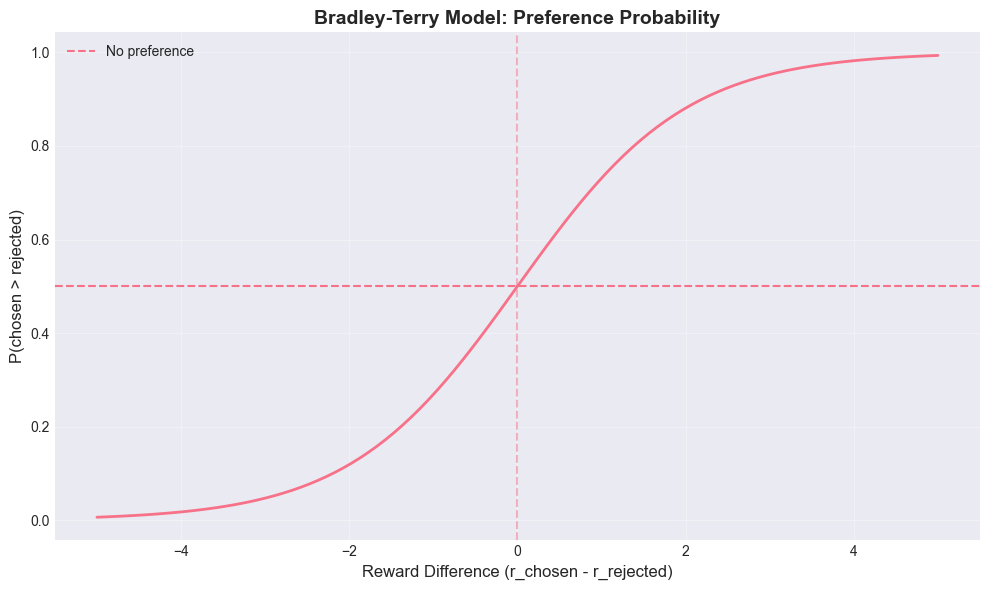


Interpretation:
  Larger reward difference → higher preference probability
  Equal rewards → 50% probability (no preference)
  Sigmoid shape keeps probabilities between 0 and 1


In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Demonstrate Bradley-Terry model
def bradley_terry_probability(reward_w, reward_l):
    """Calculate probability of preferring response with reward_w over reward_l."""
    return 1 / (1 + np.exp(reward_l - reward_w))

# Example rewards
print("Bradley-Terry Model Examples:\n")
print("=" * 60)

examples = [
    (5.0, 3.0, "Clear preference"),
    (4.0, 3.9, "Slight preference"),
    (3.0, 3.0, "No preference"),
    (2.0, 5.0, "Wrong order (low probability)"),
]

for r_w, r_l, description in examples:
    prob = bradley_terry_probability(r_w, r_l)
    print(f"\n{description}:")
    print(f"  Reward(preferred) = {r_w:.1f}")
    print(f"  Reward(rejected)  = {r_l:.1f}")
    print(f"  P(preferred > rejected) = {prob:.4f}")
    print("-" * 60)

# Visualize
reward_diffs = np.linspace(-5, 5, 100)
probs = [bradley_terry_probability(r, 0) for r in reward_diffs]

plt.figure(figsize=(10, 6))
plt.plot(reward_diffs, probs, linewidth=2)
plt.axhline(y=0.5, linestyle='--', label='No preference')
plt.axvline(x=0, linestyle='--', alpha=0.5)
plt.xlabel('Reward Difference (r_chosen - r_rejected)', fontsize=12)
plt.ylabel('P(chosen > rejected)', fontsize=12)
plt.title('Bradley-Terry Model: Preference Probability', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("  Larger reward difference → higher preference probability")
print("  Equal rewards → 50% probability (no preference)")
print("  Sigmoid shape keeps probabilities between 0 and 1")


## From Preferences to a Reward Model

Humans do not provide numeric scores.

Instead, we learn a reward function from pairwise preferences.

### Reward Model

A neural network assigns a scalar score:

$$
r_\phi(x, y) \in \mathbb{R}
$$

Where:
- $x$ = prompt  
- $y$ = response  
- $\phi$ = reward model parameters

### Bradley–Terry Probability

$$
P_\phi(y_w \succ y_l \mid x) = \sigma \big( r_\phi(x, y_w) - r_\phi(x, y_l) \big)
$$

With the sigmoid:

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

### Reward Model Loss

$$
\mathcal{L}_{RM}(\phi) = - \log P_\phi(y_w \succ y_l \mid x)
$$

Equivalently:

$$
\mathcal{L}_{RM}(\phi) = - \log \sigma \big( r_\phi(x, y_w) - r_\phi(x, y_l) \big)
$$

### Key Idea

If the chosen response is better, training pushes:

$$
r_\phi(x, y_w) > r_\phi(x, y_l)
$$

The model learns scores even though humans only gave preferences.


## 2.5 RLHF: Big Picture (Intuition)

Reinforcement Learning from Human Feedback (RLHF) is how we turn a
“polite but imperfect” model into one that better matches human
preferences.

### Three Stages (Conceptually)

1. **Supervised Fine-Tuning (SFT)**
   - Train on instruction → response pairs.
   - Model learns: “When I see this kind of prompt, I should respond like this.”

2. **Reward Model Training**
   - For each prompt, get multiple responses.
   - Humans (or a stronger model) say which one is better.
   - Train a model that assigns a higher score to the preferred response.

3. **RL Fine-Tuning (PPO)**
   - Let the model generate answers.
   - Reward model scores them.
   - Update the model to make high-score answers more likely,
     while not drifting too far from the SFT model.

### Intuitive Example

Prompt: “Should I invest in stocks?”

- **Raw pre-trained LM**: Might say something overly confident or risky.
- **After SFT**: More likely to mention uncertainty, but still inconsistent.
- **After RLHF**: Consistently says something like  
  “I can’t give personalized financial advice. Consider consulting a financial advisor…”  
  because that style is repeatedly preferred and rewarded.


## 2.5 RLHF: High-Level Idea (No Algorithms Yet)

Reinforcement Learning from Human Feedback (RLHF) builds on two pieces:

1. **Base model (SFT)**  
   - Trained on instruction → response pairs  
   - Knows how to *roughly* follow instructions

2. **Reward model**  
   - Trained from human (or AI) preferences  
   - Given $(x, y)$, outputs a score $r(x, y)$  
   - Higher score = “humans like this answer more”

### RLHF Step (Conceptual)

For each prompt $x$:

1. The model generates a response $y$  
2. The reward model gives a score $r(x, y)$  
3. We tweak the model so that:
   - High-reward responses become **more likely**
   - Low-reward responses become **less likely**
   - But we keep it **close to the original SFT model**

Think of it as:
- “Move toward answers humans prefer”
- “Stay near the safe base behavior”


## RLHF: Intuitive Objective

We can think of the RLHF update as trying to maximize:

$$
\text{Objective} \approx \underbrace{r(x, y)}_{\text{be more like preferred answers}}
\;-\;
\underbrace{\beta \cdot \text{Distance}(\pi_\theta, \pi_{\text{ref}})}_{\text{do not drift too far}}
$$

Where:

- $r(x, y)$ = reward from the reward model  
- $\pi_\theta$ = current model (policy)  
- $\pi_{\text{ref}}$ = reference model (often the SFT model)  
- $\beta$ = how strongly we penalize large changes

**Intuition:**

- First term: “Make high-scoring (preferred) answers more likely.”  
- Second term: “But keep the new model similar to the old one.”

In practice, people use RL algorithms (like PPO) to implement this,  
but the key idea is just:
> *“Increase reward, gently, without letting the model go off the rails.”*


## 2.6 Beyond RLHF: Alternatives to RL with PPO

RLHF (with an RL algorithm) is one way to use preferences, but not the only one.

### 1. Direct Preference Optimization (DPO) and similar

- Use the same preference data (chosen vs rejected)
- Optimize the model **directly** to prefer $y_w$ over $y_l$
- No separate RL loop needed
- Still uses ideas like the Bradley–Terry model

### 2. Filtered / Rejection Sampling

- Train an SFT model
- Generate many responses
- Keep only the best ones according to:
  - reward model  
  - or a stronger model  
- Optionally fine-tune again on these “better” samples

### 3. RLAIF (Reinforcement Learning from AI Feedback)

- Same structure as RLHF
- But preferences come from a **stronger model** instead of humans
- Cheaper to scale, humans mainly used for spot-checking and calibration

All of these share the same core idea:

- Use **preference data** to shape the model  
- Either with RL (like RLHF) or **direct optimization** (like DPO)  
- Always trying to match **what humans prefer** while keeping the model stable


## Direct Preference Optimization (DPO)

### Motivation

**Problems with RLHF**:
- Complex: Requires training separate reward model
- Unstable: PPO training can be difficult
- Expensive: Need to run RL optimization

**DPO Solution**: Direct optimization on preference data
- No separate reward model needed
- No RL algorithm needed
- Simpler and more stable

### Key Insight

Directly optimize the policy using preference data, bypassing reward modeling.

### DPO Objective

**Loss function**:

$$
\mathcal{L}_{DPO} = -\mathbb{E}_{(x, y_w, y_l)} \left[ \log \sigma \left( \beta \log \frac{\pi_\theta(y_w|x)}{\pi_{\text{ref}}(y_w|x)} - \beta \log \frac{\pi_\theta(y_l|x)}{\pi_{\text{ref}}(y_l|x)} \right) \right]
$$

**Simplified interpretation**:
- Increase probability of chosen response
- Decrease probability of rejected response
- Maintain KL divergence constraint with reference model

### Advantages of DPO

1. **Simpler**: Single-stage training
2. **More stable**: No RL instability
3. **Efficient**: No reward model inference
4. **Effective**: Comparable or better results than RLHF

### RLHF vs. DPO Comparison

| Aspect | RLHF | DPO |
|--------|------|-----|
| Stages | 3 (SFT → RM → PPO) | 2 (SFT → DPO) |
| Reward Model | Yes, separate model | No, implicit |
| Optimization | PPO (complex) | Supervised learning |
| Stability | Can be unstable | More stable |
| Efficiency | Lower | Higher |

In [16]:
# Conceptual comparison of RLHF and DPO
import textwrap

def print_pipeline_comparison():
    print("Training Pipeline Comparison\n")
    print("=" * 80)

    print("\nRLHF (3 stages):")
    print("  1. SFT: Pre-trained model → Instruction-tuned model")
    print("  2. Reward Model: Preference data → Reward model")
    print("  3. PPO: Use reward model to optimize policy via RL")
    print("\n  Complexity: HIGH")
    print("  Components: LM + Reward Model + PPO")

    print("\n" + "-" * 80)

    print("\nDPO (2 stages):")
    print("  1. SFT: Pre-trained model → Instruction-tuned model")
    print("  2. DPO: Directly optimize on preference data")
    print("\n  Complexity: MEDIUM")
    print("  Components: LM only")

    print("\n" + "=" * 80)

    # Training data comparison
    print("\n\nData Requirements:\n")
    print("Both require:")
    print("   SFT data: Instruction-response pairs")
    print("   Preference data: (prompt, chosen, rejected) tuples")

    # Performance comparison
    print("\n\nEmpirical Results:")
    print("   DPO often matches or exceeds RLHF performance")
    print("   DPO is faster and more stable to train")
    print("   DPO has become preferred method for many applications")


print_pipeline_comparison()


Training Pipeline Comparison


RLHF (3 stages):
  1. SFT: Pre-trained model → Instruction-tuned model
  2. Reward Model: Preference data → Reward model
  3. PPO: Use reward model to optimize policy via RL

  Complexity: HIGH
  Components: LM + Reward Model + PPO

--------------------------------------------------------------------------------

DPO (2 stages):
  1. SFT: Pre-trained model → Instruction-tuned model
  2. DPO: Directly optimize on preference data

  Complexity: MEDIUM
  Components: LM only



Data Requirements:

Both require:
   SFT data: Instruction-response pairs
   Preference data: (prompt, chosen, rejected) tuples


Empirical Results:
   DPO often matches or exceeds RLHF performance
   DPO is faster and more stable to train
   DPO has become preferred method for many applications


## 2.7 Test-Time Compute: Chain-of-Thought Prompting

### Motivation

**Problem**: Complex reasoning tasks require multiple steps

**Example**:
- Question: "If a train travels 60 mph for 2.5 hours, how far does it go?"
- Direct answer: May be wrong without intermediate steps
- With reasoning: More likely to be correct

### Chain-of-Thought (CoT) Prompting

**Idea**: Encourage model to show its reasoning steps

**Standard prompting**:
```
Q: If a train travels 60 mph for 2.5 hours, how far does it go?
A: 150 miles
```

**Chain-of-Thought prompting**:
```
Q: If a train travels 60 mph for 2.5 hours, how far does it go?
A: Let's think step by step.
- Speed: 60 mph
- Time: 2.5 hours
- Distance = Speed × Time
- Distance = 60 × 2.5 = 150 miles
Therefore, the train travels 150 miles.
```

### Implementation Strategies

**Few-shot CoT**:
- Provide examples with reasoning steps
- Model learns to replicate the pattern

**Zero-shot CoT**:
- Simply add "Let's think step by step."
- Surprisingly effective for many tasks!

### Benefits

1. **Improved accuracy** on complex reasoning
2. **Interpretability**: Can see model's reasoning
3. **Error detection**: Can identify where reasoning fails
4. **Debugging**: Can correct specific reasoning steps

In [17]:
# Demonstrate Chain-of-Thought prompting
# Note: This is a demonstration - actual results depend on the model used

# Math word problem
problem = """A baker makes 12 cupcakes per batch.
If they make 5 batches in the morning and 3 batches in the afternoon,
how many cupcakes did they make in total?"""

# Standard prompt
standard_prompt = f"""Question: {problem}
Answer:"""

# Chain-of-Thought prompt
cot_prompt = f"""Question: {problem}
Answer: Let's solve this step by step."""

# Few-shot CoT (with examples)
few_shot_cot = """Question: A restaurant serves 8 tables. Each table has 4 customers. How many customers in total?
Answer: Let's solve this step by step.
- Tables: 8
- Customers per table: 4
- Total customers = Tables × Customers per table
- Total customers = 8 × 4 = 32
Therefore, there are 32 customers in total.

Question: A baker makes 12 cupcakes per batch. If they make 5 batches in the morning and 3 batches in the afternoon, how many cupcakes did they make in total?
Answer: Let's solve this step by step."""

print("Chain-of-Thought Prompting Strategies\n")
print("=" * 80)

print("\n1. STANDARD PROMPT (no reasoning):")
print("-" * 80)
print(standard_prompt)
print("\nExpected: Direct answer (may be wrong)")

print("\n\n2. ZERO-SHOT CoT (add 'step by step'):")
print("-" * 80)
print(cot_prompt)
print("\nExpected: Shows reasoning steps")

print("\n\n3. FEW-SHOT CoT (provide example):")
print("-" * 80)
print(few_shot_cot)
print("\nExpected: Follows example format")

# Expected CoT output
print("\n\n" + "=" * 80)
print("Expected CoT Response:")
print("=" * 80)
expected_cot = """- Cupcakes per batch: 12
- Morning batches: 5
- Afternoon batches: 3
- Total batches = 5 + 3 = 8
- Total cupcakes = 12 × 8 = 96
Therefore, the baker made 96 cupcakes in total."""
print(expected_cot)

print("\n" + "=" * 80)
print("\n Key Benefits of CoT:")
print("   Breaks complex problems into manageable steps")
print("   Makes reasoning transparent and verifiable")
print("   Improves accuracy on multi-step reasoning tasks")
print("   Enables error detection and correction")

Chain-of-Thought Prompting Strategies


1. STANDARD PROMPT (no reasoning):
--------------------------------------------------------------------------------
Question: A baker makes 12 cupcakes per batch.
If they make 5 batches in the morning and 3 batches in the afternoon,
how many cupcakes did they make in total?
Answer:

Expected: Direct answer (may be wrong)


2. ZERO-SHOT CoT (add 'step by step'):
--------------------------------------------------------------------------------
Question: A baker makes 12 cupcakes per batch.
If they make 5 batches in the morning and 3 batches in the afternoon,
how many cupcakes did they make in total?
Answer: Let's solve this step by step.

Expected: Shows reasoning steps


3. FEW-SHOT CoT (provide example):
--------------------------------------------------------------------------------
Question: A restaurant serves 8 tables. Each table has 4 customers. How many customers in total?
Answer: Let's solve this step by step.
- Tables: 8
- Customers per ta

## 2.8 Advanced CoT Techniques

### Self-Consistency

**Idea**: Generate multiple reasoning paths and take majority vote

**Process**:
1. Sample N different CoT reasoning paths (with temperature > 0)
2. Extract final answer from each path
3. Take majority vote

**Benefits**: More robust, reduces impact of individual errors

### Tree of Thoughts (ToT)

**Idea**: Explore multiple reasoning branches like a search tree

**Process**:
1. Generate multiple next steps at each stage
2. Evaluate each step (which looks most promising?)
3. Expand most promising branches
4. Use search algorithm (BFS, DFS, beam search)

**Use cases**: Requires extensive exploration (e.g., game of 24, creative writing)

### Least-to-Most Prompting

**Idea**: Break problem into subproblems, solve from easiest to hardest

**Example**:
- Complex: "What's the total cost of 3 shirts at $25 each and 2 pants at $40 each with 10% discount?"
- Subproblem 1: Cost of shirts
- Subproblem 2: Cost of pants
- Subproblem 3: Total before discount
- Subproblem 4: Apply discount

### Program-Aided Language Models (PAL)

**Idea**: Generate code to solve the problem, then execute it

**Benefits**:
- Leverage programming for precise computation
- Avoid arithmetic errors
- Can handle complex calculations

In [18]:
# Demonstrate Self-Consistency with simulated reasoning paths
from collections import Counter

def demonstrate_self_consistency():
    problem = "A garden has 4 rows of plants. Each row has 7 plants. If 5 plants die, how many are left?"

    # Simulated reasoning paths (in practice, these come from model sampling)
    reasoning_paths = [
        {
            "reasoning": "4 rows × 7 plants = 28 plants. Then 28 - 5 = 23 plants.",
            "answer": 23
        },
        {
            "reasoning": "Total: 4 × 7 = 28. Dead: 5. Remaining: 28 - 5 = 23.",
            "answer": 23
        },
        {
            "reasoning": "Each row has 7. With 4 rows: 7+7+7+7=28. Subtract 5 dead: 23.",
            "answer": 23
        },
        {
            # Incorrect reasoning / arithmetic on purpose
            "reasoning": "Compute total: 4 × 7 = 28. Maybe I miscount and think 6 died: 28 - 4 = 24.",
            "answer": 24
        },
        {
            "reasoning": "Start with 28 plants (4×7). Remove 5. Left with 28-5=23.",
            "answer": 23
        }
    ]

    print("Self-Consistency Example\n")
    print("=" * 80)
    print(f"Problem: {problem}\n")
    print("Generated Reasoning Paths:")
    print("-" * 80)

    answers = []
    for i, path in enumerate(reasoning_paths, 1):
        print(f"\nPath {i}:")
        print(f"  {path['reasoning']}")
        print(f"  Answer: {path['answer']}")
        answers.append(path['answer'])

    # Majority vote
    vote_counts = Counter(answers)
    majority_answer = vote_counts.most_common(1)[0][0]

    print("\n" + "=" * 80)
    print(f"\nMajority Vote: {majority_answer}")
    print(f"Vote distribution: {dict(vote_counts)}")
    print("\nSelf-Consistency Benefits:")
    print("  • Multiple reasoning paths reduce error risk")
    print("  • Majority voting can correct occasional mistakes")
    print("  • Useful even when some individual paths are wrong")


demonstrate_self_consistency()


Self-Consistency Example

Problem: A garden has 4 rows of plants. Each row has 7 plants. If 5 plants die, how many are left?

Generated Reasoning Paths:
--------------------------------------------------------------------------------

Path 1:
  4 rows × 7 plants = 28 plants. Then 28 - 5 = 23 plants.
  Answer: 23

Path 2:
  Total: 4 × 7 = 28. Dead: 5. Remaining: 28 - 5 = 23.
  Answer: 23

Path 3:
  Each row has 7. With 4 rows: 7+7+7+7=28. Subtract 5 dead: 23.
  Answer: 23

Path 4:
  Compute total: 4 × 7 = 28. Maybe I miscount and think 6 died: 28 - 4 = 24.
  Answer: 24

Path 5:
  Start with 28 plants (4×7). Remove 5. Left with 28-5=23.
  Answer: 23


Majority Vote: 23
Vote distribution: {23: 4, 24: 1}

Self-Consistency Benefits:
  • Multiple reasoning paths reduce error risk
  • Majority voting can correct occasional mistakes
  • Useful even when some individual paths are wrong


In [19]:
# Demonstrate Program-Aided Language Models (PAL)
def demonstrate_pal():
    problem = (
        "A store sells apples at $2.50 per pound. If you buy 3.5 pounds with a "
        "15% discount, what's the final price?"
    )

    # PAL approach: Generate code instead of reasoning in natural language
    generated_code = """
# Calculate final price
price_per_pound = 2.50
pounds = 3.5
discount_rate = 0.15

# Calculate subtotal
subtotal = price_per_pound * pounds

# Apply discount
discount_amount = subtotal * discount_rate
final_price = subtotal - discount_amount

print(f"Subtotal: ${subtotal:.2f}")
print(f"Discount: ${discount_amount:.2f}")
print(f"Final price: ${final_price:.2f}")
"""

    print("Program-Aided Language Models (PAL)\n")
    print("=" * 80)
    print(f"Problem: {problem}\n")
    print("Generated Code:")
    print("-" * 80)
    print(generated_code)
    print("-" * 80)

    # Execute the code
    print("\nExecution Result:")
    print("-" * 80)
    exec(generated_code)
    print("-" * 80)

    print("\nPAL Advantages:")
    print("  • Precise arithmetic (no calculation errors)")
    print("  • Clear step-by-step logic in code")
    print("  • Can handle complex mathematical operations")
    print("  • Code is executable and verifiable")


demonstrate_pal()


Program-Aided Language Models (PAL)

Problem: A store sells apples at $2.50 per pound. If you buy 3.5 pounds with a 15% discount, what's the final price?

Generated Code:
--------------------------------------------------------------------------------

# Calculate final price
price_per_pound = 2.50
pounds = 3.5
discount_rate = 0.15

# Calculate subtotal
subtotal = price_per_pound * pounds

# Apply discount
discount_amount = subtotal * discount_rate
final_price = subtotal - discount_amount

print(f"Subtotal: ${subtotal:.2f}")
print(f"Discount: ${discount_amount:.2f}")
print(f"Final price: ${final_price:.2f}")

--------------------------------------------------------------------------------

Execution Result:
--------------------------------------------------------------------------------
Subtotal: $8.75
Discount: $1.31
Final price: $7.44
--------------------------------------------------------------------------------

PAL Advantages:
  • Precise arithmetic (no calculation errors)
  • Cl

# Putting It All Together: Modern LLM Pipeline

### Complete Training Pipeline

```
1. Pre-training
↓ (Massive unlabeled corpus)
Base LLM

2. Instruction Tuning (SFT)
↓ (Instruction-response pairs)
Instruction-following LLM

3. Preference Alignment (DPO/RLHF)
↓ (Human preferences)
Aligned LLM

4. Test-Time Compute (CoT)
↓ (Prompting strategies)
Enhanced reasoning
```

### Key Takeaways

**Masked Language Models (BERT)**:
- Bidirectional context for better understanding
- MLM training: 15% masking with 80/10/10 strategy
- Contextual embeddings solve polysemy
- Fine-tune for downstream tasks (classification, NER, etc.)

**LLM Post-Training**:
- Instruction tuning: Teach model to follow instructions
- Preference alignment: Align with human values
- RLHF: 3-stage process with reward model and PPO
- DPO: Direct optimization, simpler and more stable
- Test-time compute: CoT prompting for better reasoning

**Modern Best Practices**:
1. Pre-train on large corpus
2. Instruction-tune on diverse tasks
3. Align with DPO (simpler than RLHF)
4. Use CoT prompting for complex reasoning
5. Apply self-consistency for critical tasks

## Summary and Key Takeaways

### Part 1: Masked Language Models

1. **Bidirectional vs Causal**:
- BERT uses full attention (both directions)
- GPT uses causal attention (left-to-right only)

2. **MLM Training**:
- 15% token masking: 80% [MASK], 10% random, 10% unchanged
- Prevents overfitting to [MASK] token

3. **Contextual Embeddings**:
- Different vectors for same word in different contexts
- Solves polysemy problem

4. **Fine-tuning**:
- Sequence classification: Use [CLS] token
- Token classification: Use each token's embedding
- Transfer learning from pre-trained BERT

### Part 2: LLM Post-Training

1. **Instruction Tuning (SFT)**:
- Train on instruction-response pairs
- Diverse task coverage
- Creates instruction-following model

2. **Preference Alignment**:
- Learn from human preferences (chosen vs rejected)
- RLHF: 3-stage process (complex but effective)
- DPO: Direct optimization (simpler, more stable)

3. **Test-Time Compute**:
- Chain-of-Thought prompting
- Self-consistency for robustness
- PAL for precise computation

### Practical Recommendations

**For Understanding Tasks** (classification, NER, QA):
- Use BERT-style models
- Fine-tune on task-specific data

**For Generation Tasks** (summarization, dialogue):
- Use causal LMs (GPT-style)
- Apply instruction tuning
- Align with preferences (DPO recommended)

**For Complex Reasoning**:
- Use CoT prompting
- Consider self-consistency for critical applications
- Try PAL for mathematical/computational tasks

### Further Reading

- **BERT Paper**: "BERT: Pre-training of Deep Bidirectional Transformers" (Devlin et al., 2019)
- **DPO Paper**: "Direct Preference Optimization" (Rafailov et al., 2023)
- **CoT Paper**: "Chain-of-Thought Prompting Elicits Reasoning" (Wei et al., 2022)
- **Textbook**: Jurafsky & Martin, Chapter 9 (Post-training)